In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import re

In [2]:
df = pd.read_csv('../Data/CRX_fulllength_unified.csv', index_col=0)
clinvar = pd.read_csv('../Data/clinvar_missense.csv', index_col=0)

In [3]:
WT = df.head(1).copy()

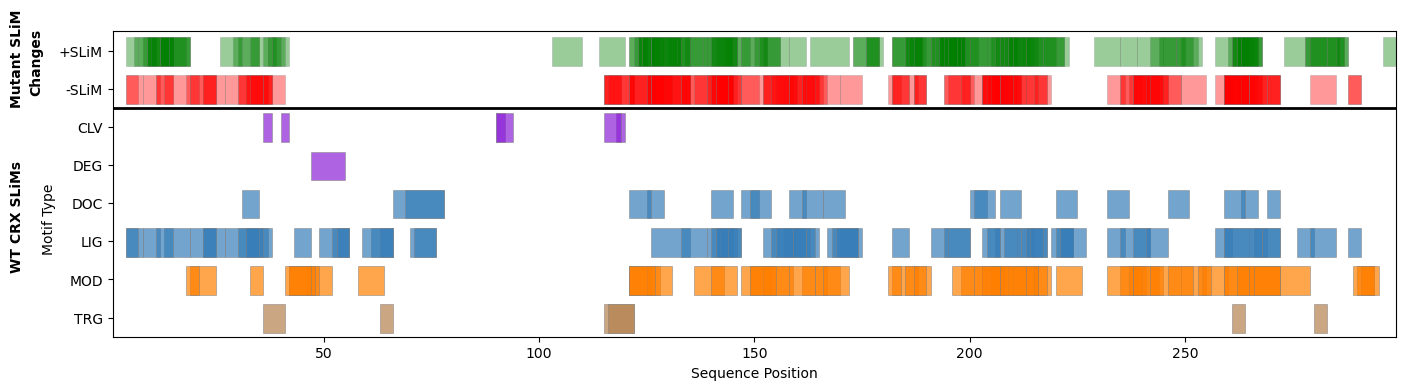

In [15]:
# Extract location ranges from format "###-###"
def parse_locations(loc_string):
    """Parse location string in format '###-###' to list of (start, end) tuples"""
    if pd.isna(loc_string) or loc_string == '':
        return []
    locations = []
    for loc in str(loc_string).split(','):
        match = re.search(r'(\d+)-(\d+)', loc.strip())
        if match:
            locations.append((int(match.group(1)), int(match.group(2))))
    return locations

def get_motif_deltas(wt_row, mut_row):
    """Compare WT and mutant motif locations and return added/deleted regions"""
    added = []
    deleted = []
    
    for motif_col in motif_types:
        wt_locs = set(parse_locations(wt_row[motif_col].values[0]))
        mut_locs = set(parse_locations(mut_row[motif_col].values[0]))
        
        # Find added and deleted regions
        for loc in mut_locs - wt_locs:
            added.append(loc)
        for loc in wt_locs - mut_locs:
            deleted.append(loc)
    
    return added, deleted

# Define motif types and colors
motif_types = ['CLV_locations', 'DEG_locations', 'DOC_locations', 
               'LIG_locations', 'MOD_locations', 'TRG_locations']
colors = ["#8c22d7", '#8c22d7', '#377eb8', '#377eb8', '#ff7f00', "#b4804d"]

# Create figure - add extra rows for deltas
fig, ax = plt.subplots(figsize=(14, 4))

# Collect all deltas from clinvar mutations
all_added = []
all_deleted = []

for protein_change in clinvar['Protein change']:
    # Find corresponding mutation in df
    mut_row = df[df['mutation'] == protein_change]
    if not mut_row.empty:
        added, deleted = get_motif_deltas(WT, mut_row)
        all_added.extend(added)
        all_deleted.extend(deleted)

# Plot +SLiM row (row -2)
for (start, end) in all_added:
    width = end - start
    rect = plt.Rectangle((start, -2.35), width, 0.75, 
                        facecolor='green', edgecolor='grey', linewidth=0.5, alpha=0.4)
    ax.add_patch(rect)

# Plot -SLiM row (row -1)
for (start, end) in all_deleted:
    width = end - start
    rect = plt.Rectangle((start, -1.35), width, 0.75, 
                        facecolor='red', edgecolor='grey', linewidth=0.5, alpha=0.4)
    ax.add_patch(rect)

# Add black separator line
ax.axhline(y=-0.5, color='black', linewidth=2, zorder=10)

# Plot each motif type in its own row
for i, (motif, color) in enumerate(zip(motif_types, colors)):
    locations = parse_locations(WT[motif].values[0])

    for (start, end) in locations:
        width = end - start
        rect = plt.Rectangle((start, i - .35), width, .75, 
                            facecolor=color, edgecolor='grey', linewidth=0.5, alpha=0.7)
        ax.add_patch(rect)

ax.text(-0.055, .28, 'Motif Type', fontsize=10, transform=ax.transAxes, rotation = 90)
ax.text(-0.08, .22, 'WT CRX SLiMs', fontweight = 'bold', fontsize=10, transform=ax.transAxes, rotation = 90)
ax.text(-0.08, .76, 'Mutant SLiM', fontweight = 'bold', fontsize=10, transform=ax.transAxes, rotation = 90)
ax.text(-0.065, .80, 'Changes', fontweight = 'bold', fontsize=10, transform=ax.transAxes, rotation = 90)

# Set axes
ax.set_xlim(1, 299)
ax.set_ylim(-2.5, len(motif_types) - 0.5)
ax.set_xlabel('Sequence Position')
ax.set_yticks([-2, -1] + list(range(len(motif_types))))
ax.set_yticklabels(['+SLiM', '-SLiM'] + [m.replace('_locations', '') for m in motif_types])
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../Graphs/Fig1/SLiMs.svg')